# Notebook 6

Testing general concepts in ABP

# Section 1

Testing histogram positions agree with predicted exponential law

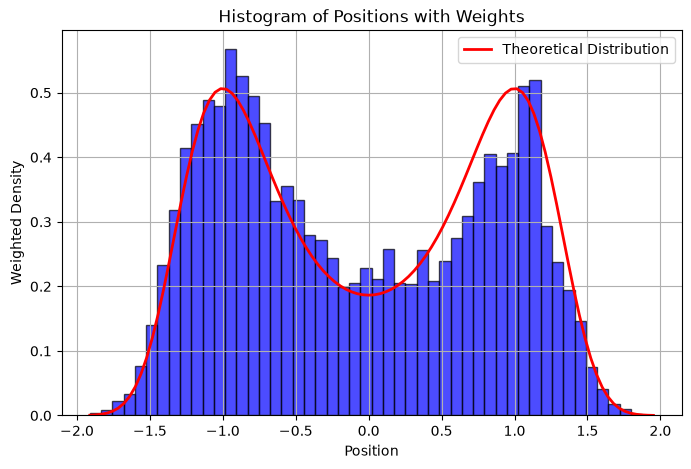

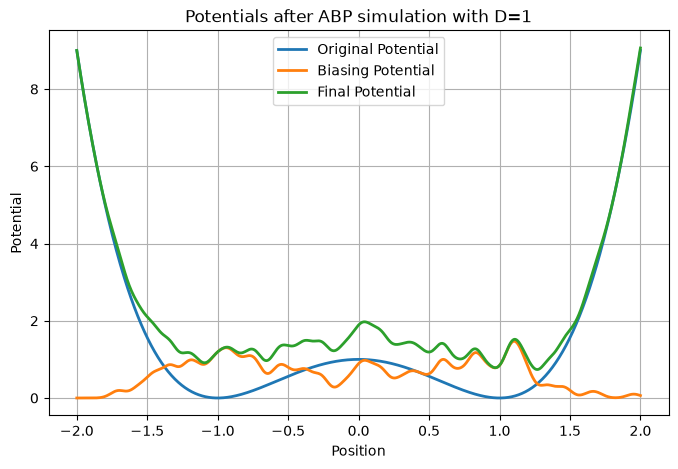

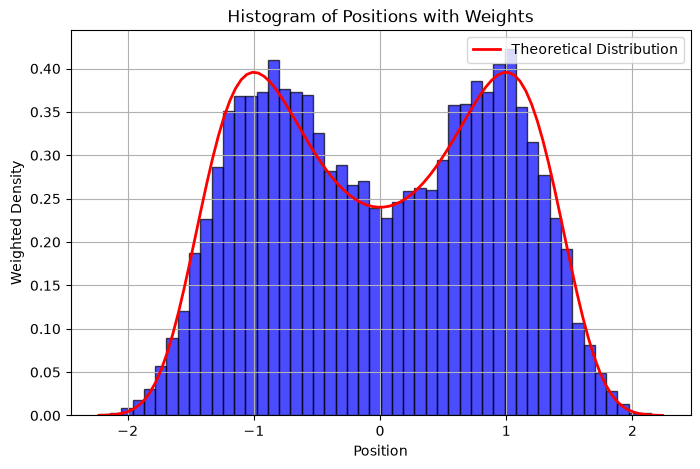

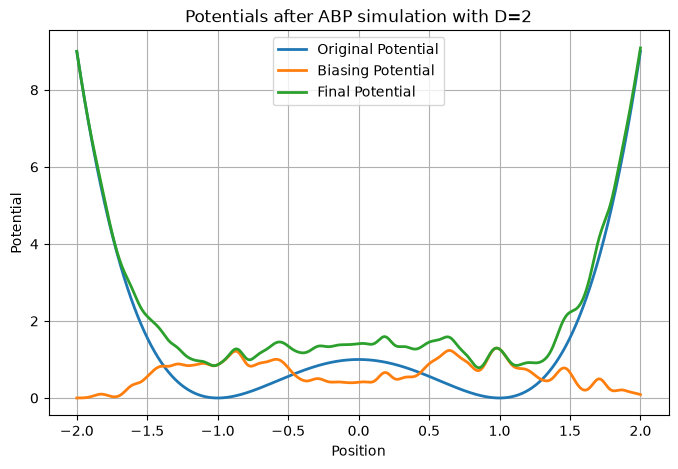

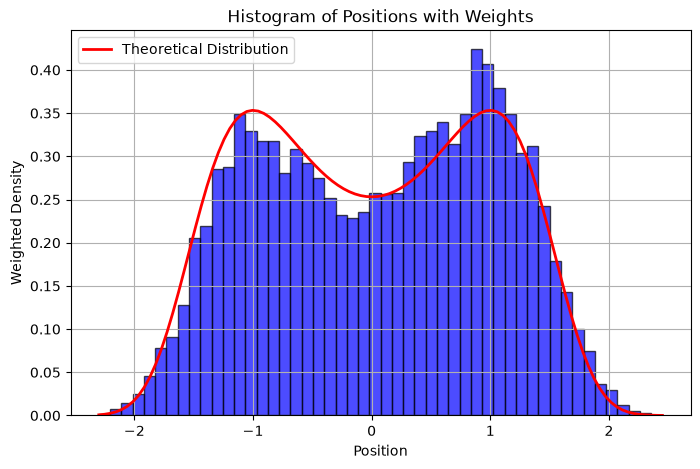

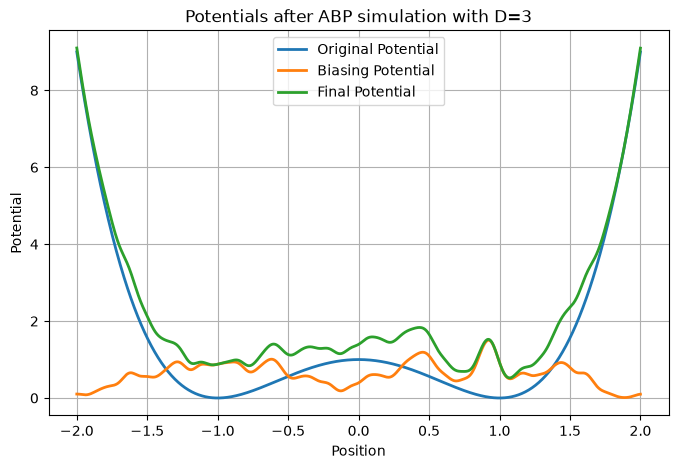

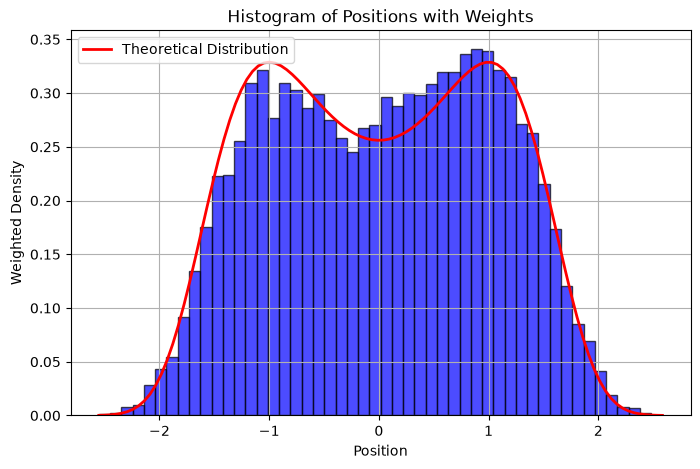

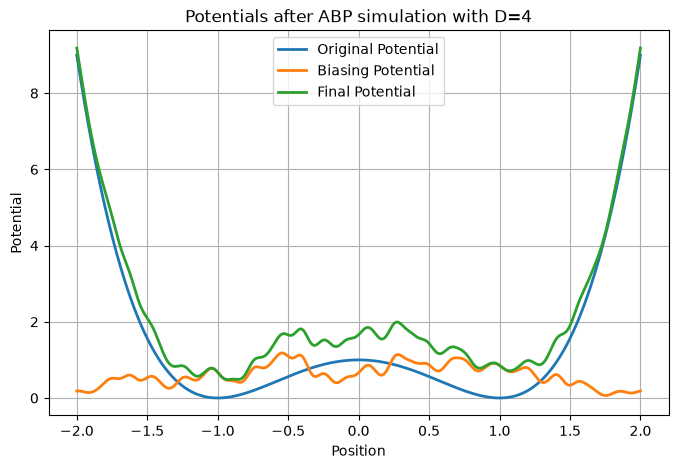

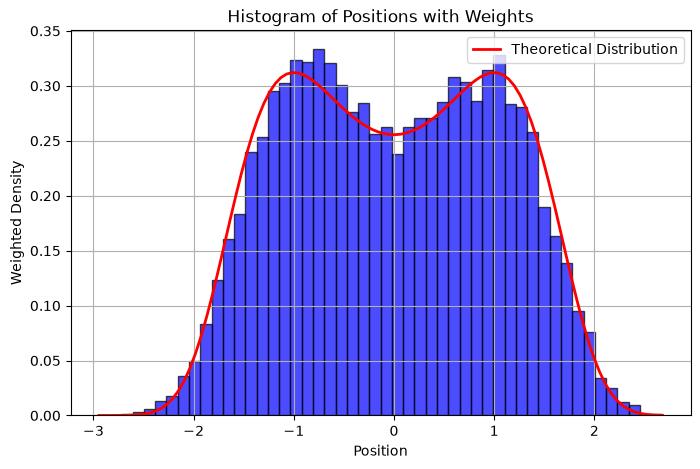

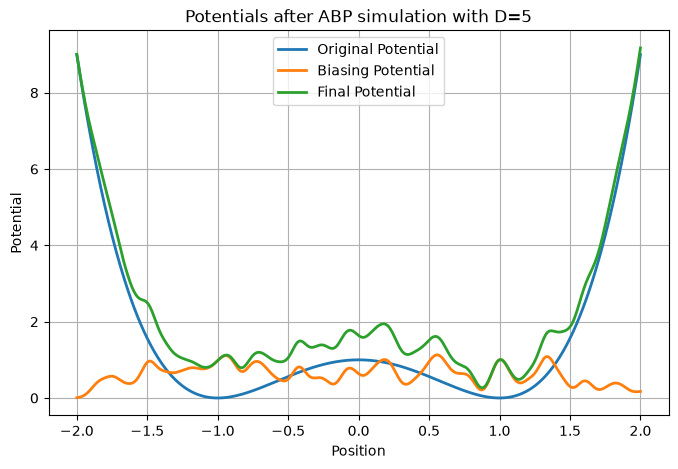

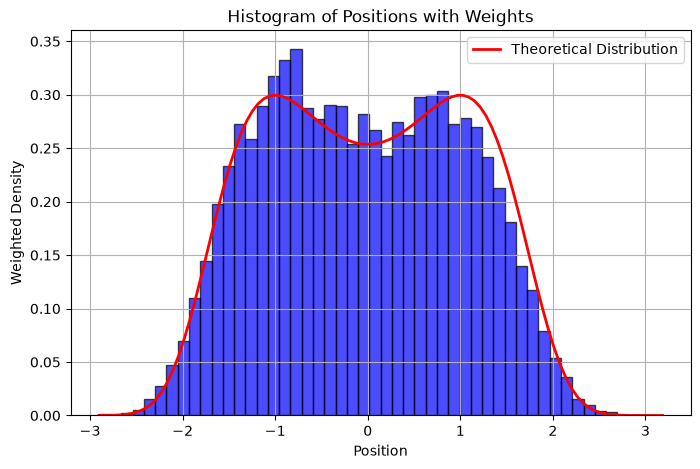

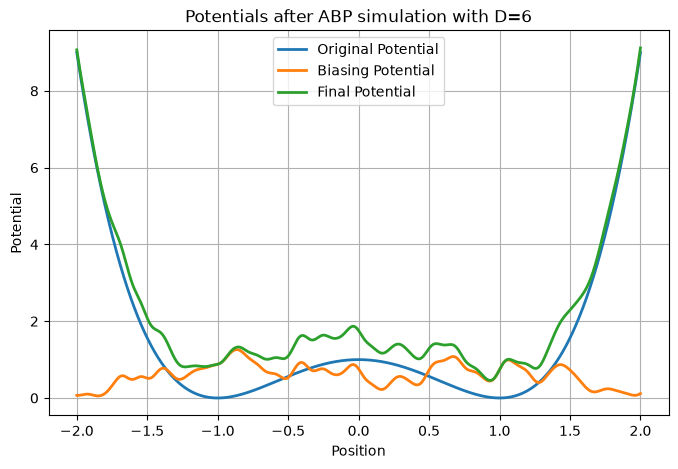

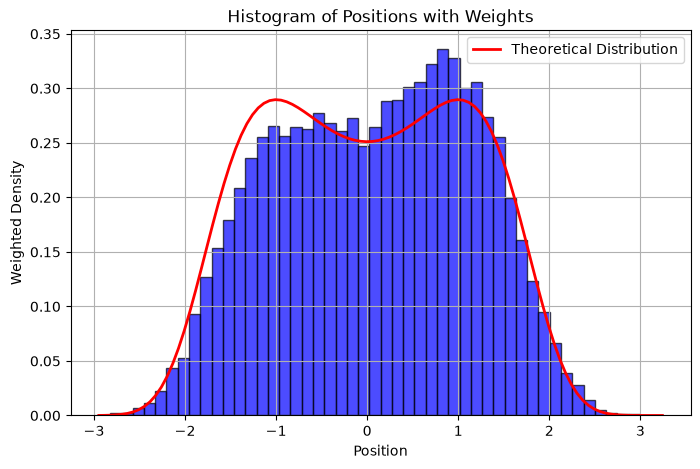

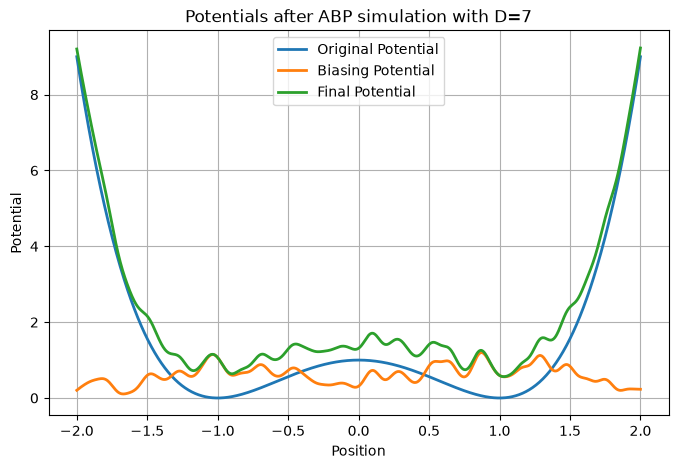

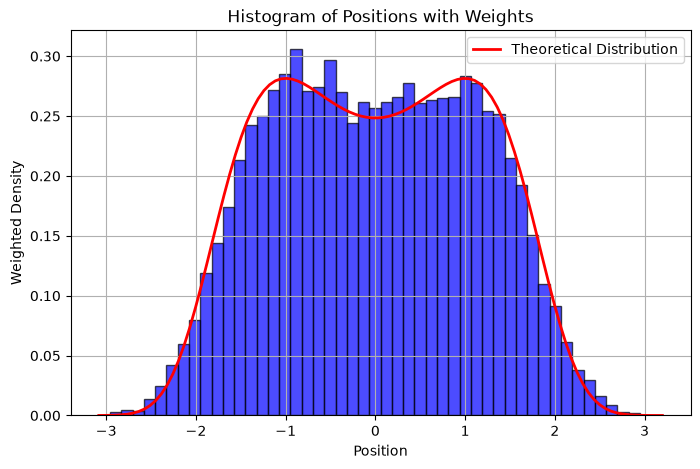

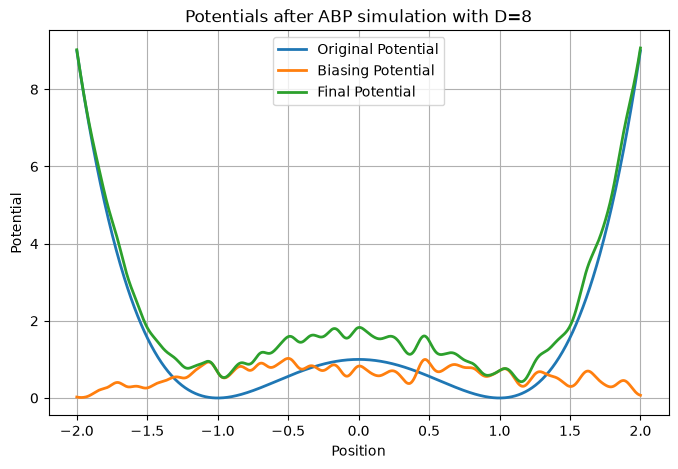

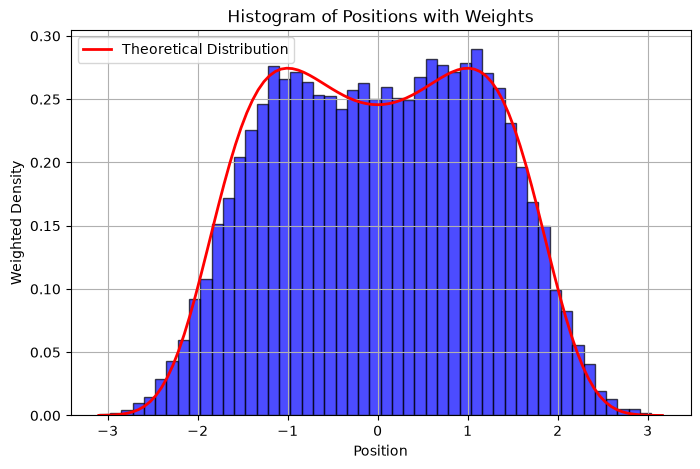

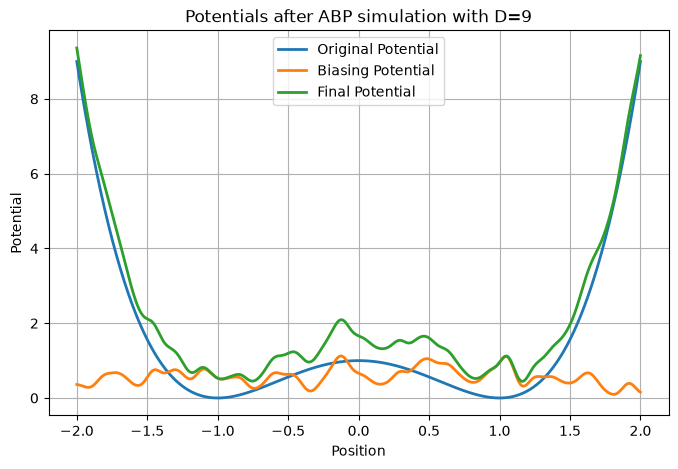

In [7]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.abp_abf.abp_metadynamics import ABPMetaDynamics


for D in np.arange(1, 10, 1):
    dt = 0.01
    potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))
    td=TransitionDetector(np.array([]), lambda x: -np.inf, 0.0)

    abp = ABPMetaDynamics(num_steps=101, td=td, delta_t=dt, dimension=1, D=D, initial_position=np.array([0.0]), b=potential, sigma=0.05)
    transition_time, simulation_time = abp.simulate(max_iters=2e4)

    abp.plot_histogram_vs_distribution(positions=abp.positions, bins=50)
    abp.plot_all_potentials(x_range=(-2, 2), num_points=1000, title="Potentials after ABP simulation with D={}".format(D))

# Section 2

Working with a 2d potential harder than the previous ones

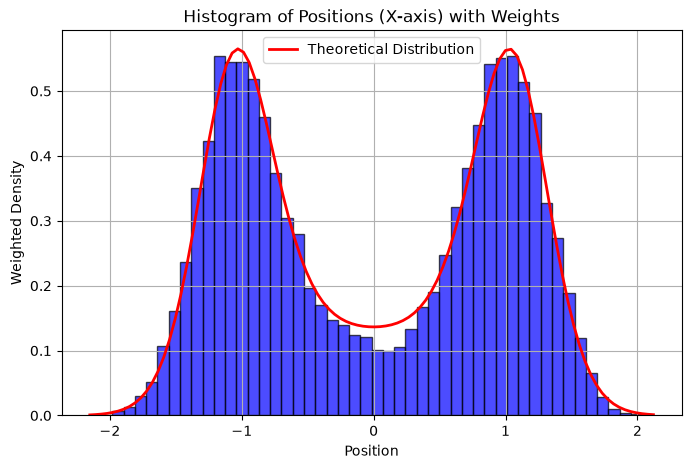

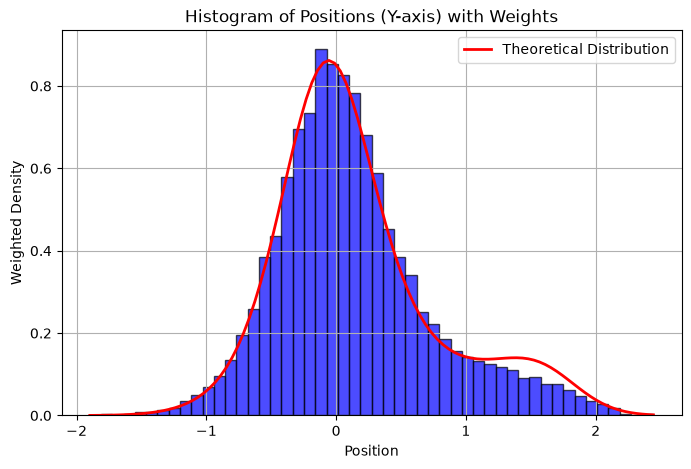

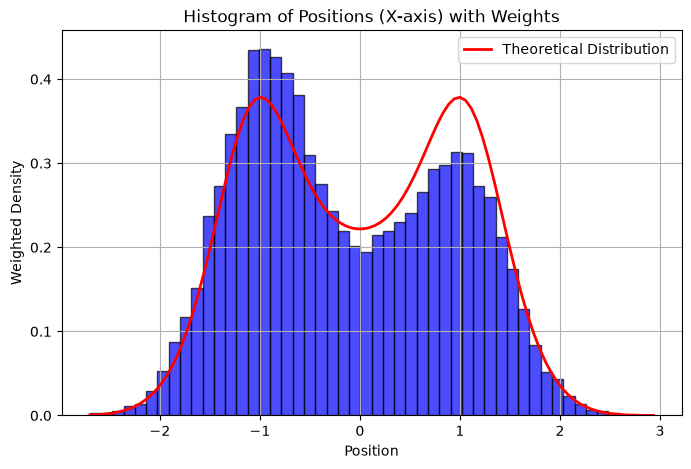

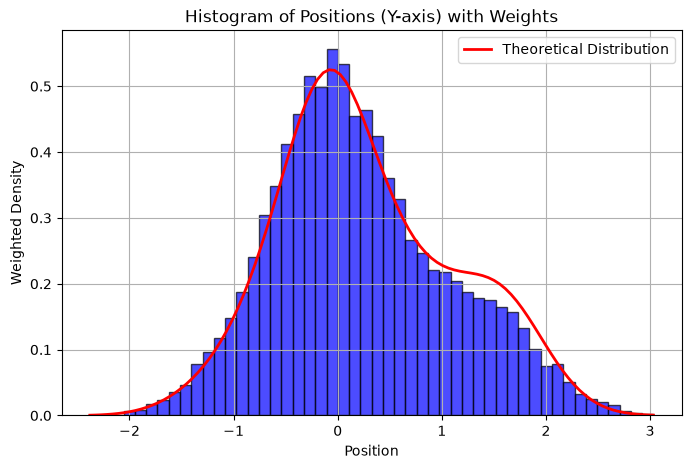

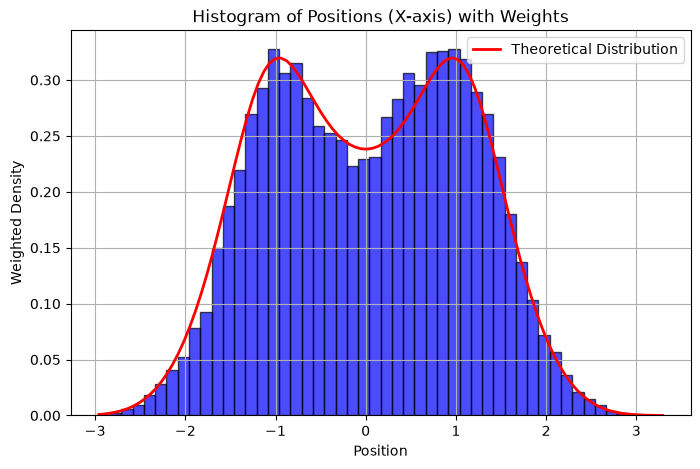

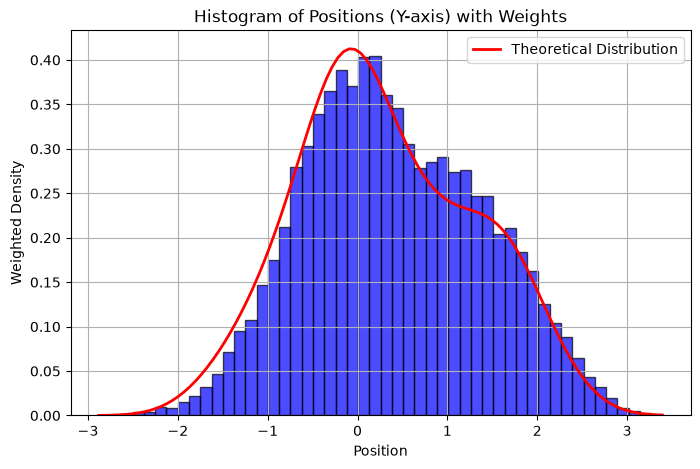

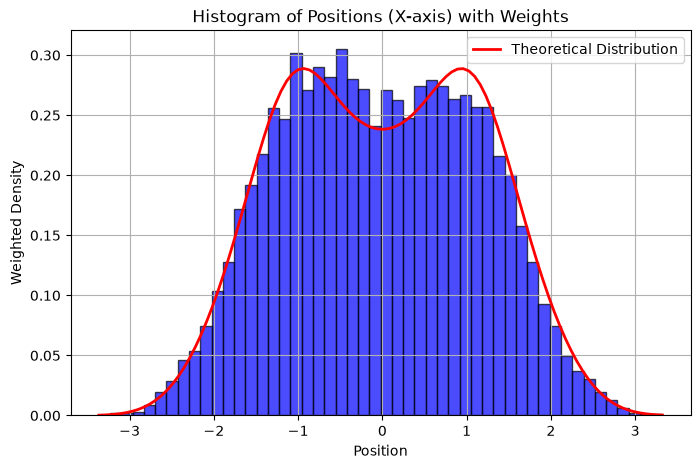

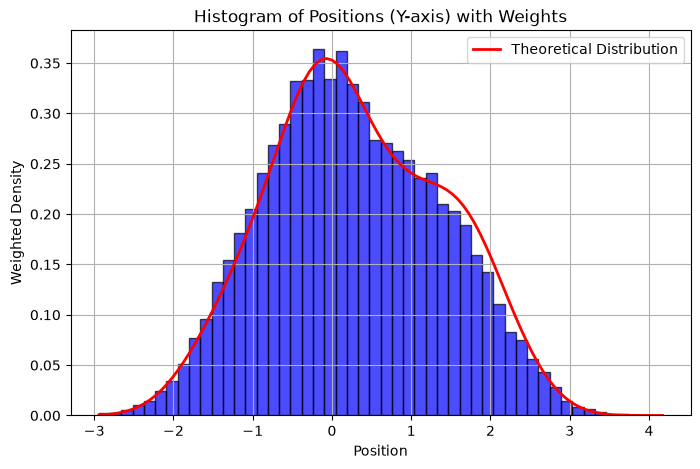

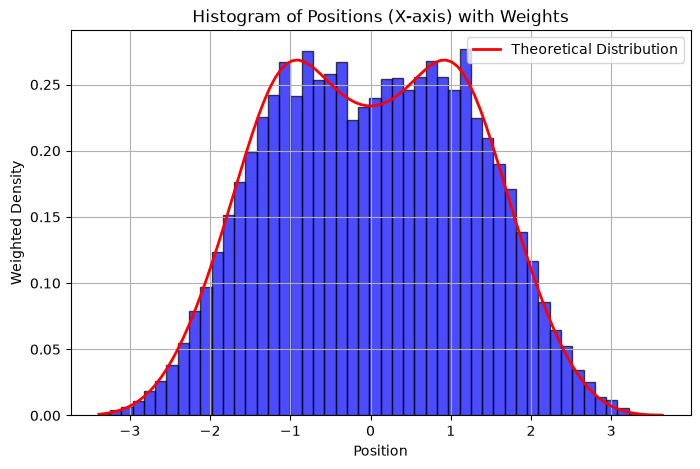

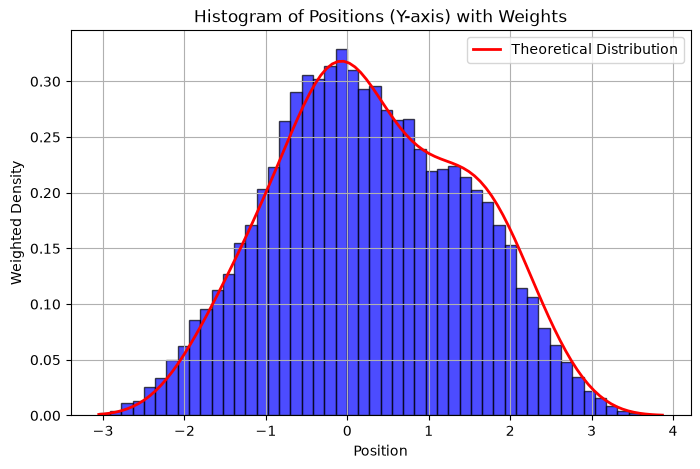

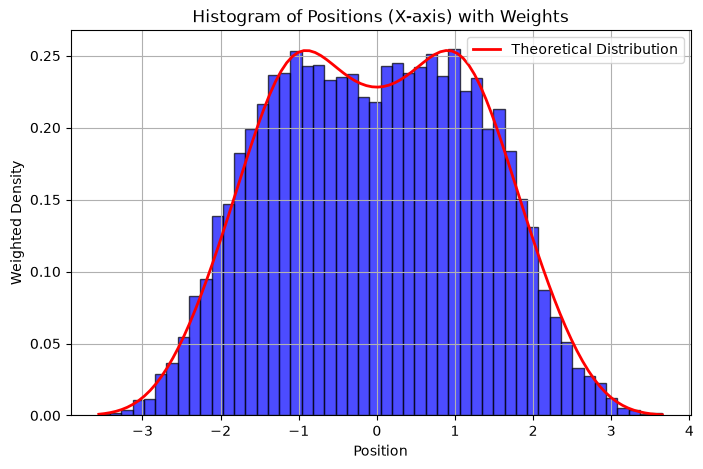

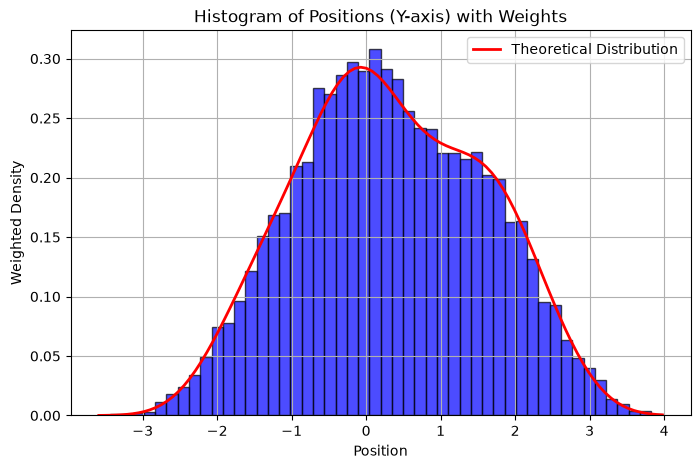

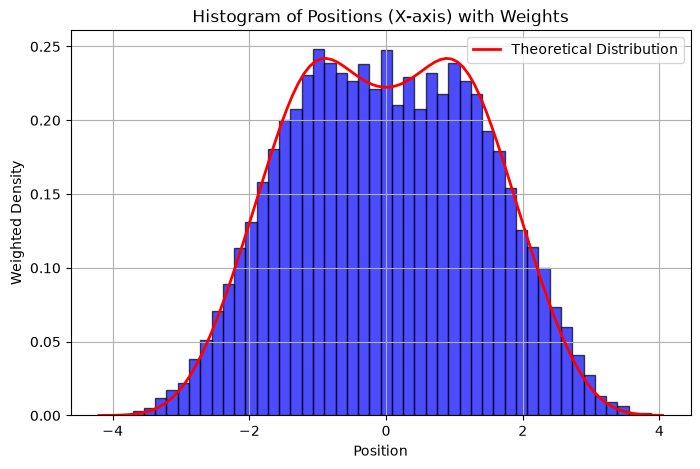

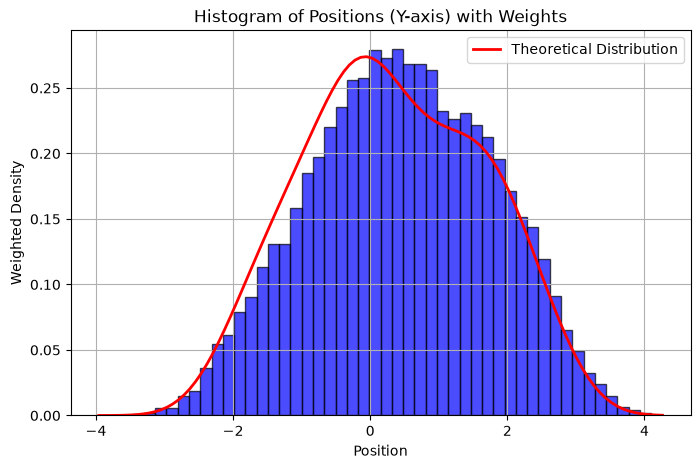

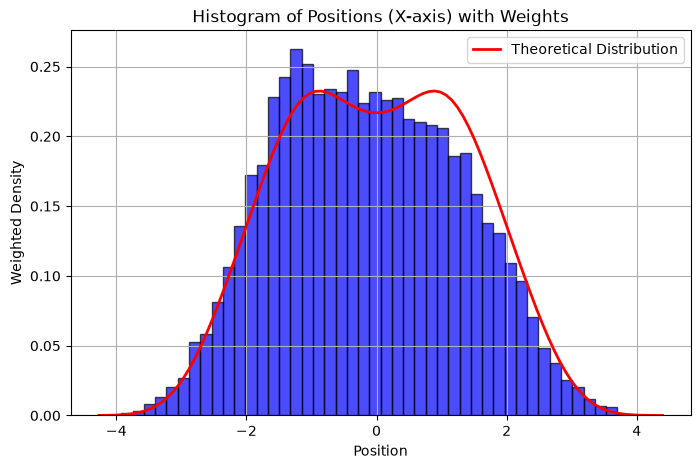

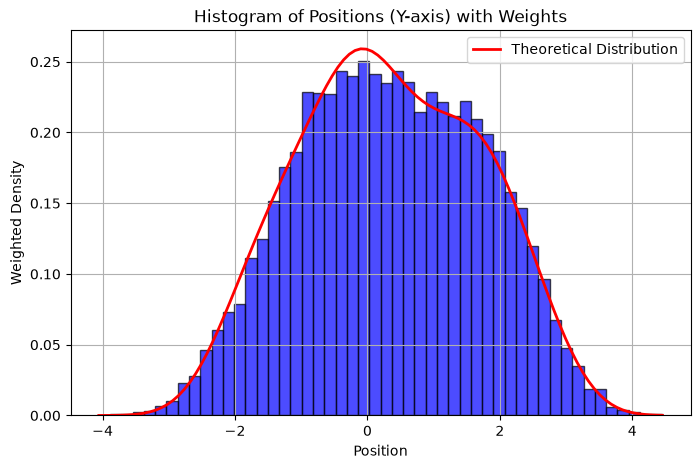

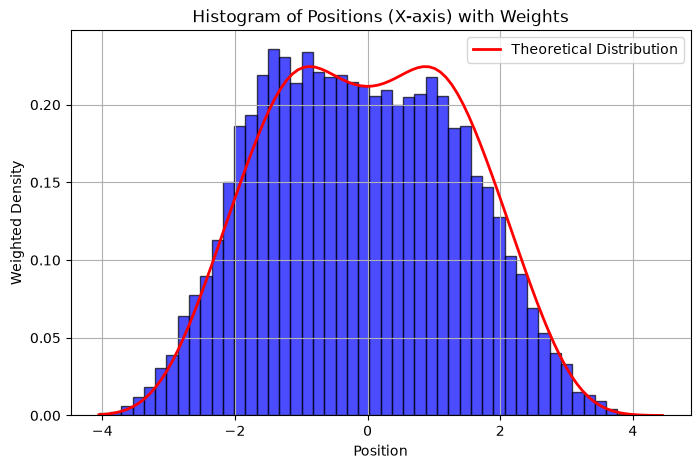

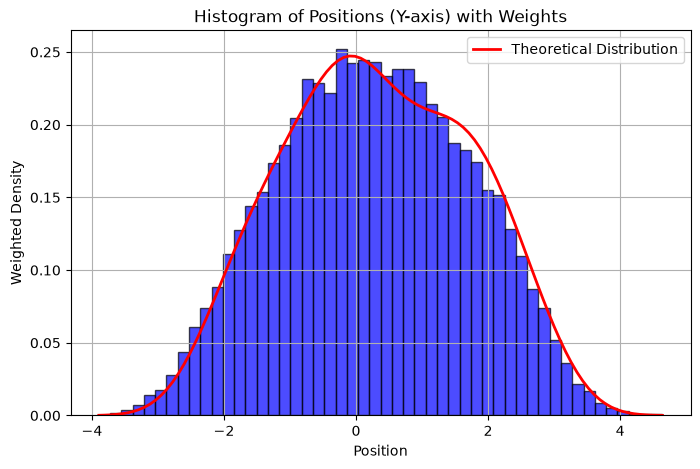

In [1]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.abp_abf.abp_metadynamics import ABPMetaDynamics

def entropic_switch(x, y):
    tmp1 = x**2
    tmp2 = (y - 1 / 3)**2
    return 3 * np.exp(-tmp1) * (np.exp(-tmp2) - np.abs(np.exp(-(y - 5 / 3)**2))) - 5 * np.exp(-y**2) * (np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2)) + 0.2 * tmp1**2 + 0.2 * tmp2**2

def grad_entropic_switch(x, y):

    tmp1 = np.exp(4*x)
    tmp2 = np.exp(-x**2 - 2*x - y**2 - 1)
    tmp3 = np.exp(-x**2)
    tmp4 = np.exp(-(y-1/3)**2)
    tmp5 = np.exp(-(y-5/3)**2)

    dx = 0.8*x**3 + 10*(tmp1*(x - 1) + x + 1)*tmp2 - 6*tmp3*x*(tmp4 - tmp5)

    dy = 10*(tmp1 + 1)*y*tmp2 + 3*tmp3*(2*tmp5*(y - 5/3) - 2*tmp4*(y - 1/3)) + 0.8*(y - 1/3)**3

    return np.array([dx, dy])


for D in np.arange(1, 10, 1):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))
    td=TransitionDetector(np.array([]), lambda x: -np.inf, 0.0)

    abp = ABPMetaDynamics(num_steps=101, td=td, delta_t=dt, dimension=2, D=D, initial_position=np.array([0.0, 0.0]), b=potential, sigma=0.05)
    transition_time, simulation_time = abp.simulate(max_iters=2e4)

    abp.plot_histogram_vs_distribution(positions=np.array(abp.positions), bins=50, dimension=2, axis=0)
    abp.plot_histogram_vs_distribution(positions=np.array(abp.positions), bins=50, dimension=2, axis=1)